# 2D forced-dissipative turbulence budgets


A simulation of forced-dissipative two-dimensional turbulence. We solve the
two-dimensional vorticity equation with stochastic excitation and dissipation in
the form of linear drag and hyperviscosity. As a demonstration, we compute how
each of the forcing and dissipation terms contribute to the energy and the
enstrophy budgets.

## Install dependencies

First let's make sure we have all required packages installed.

```julia
using Pkg
pkg"add GeophysicalFlows, CUDA, Random, Printf, CairoMakie"
```

## Let's begin
Let's load `GeophysicalFlows.jl` and some other packages we need.

In [1]:
using GeophysicalFlows, CUDA, Random, Printf, CairoMakie

parsevalsum = FourierFlows.parsevalsum
record = CairoMakie.record                # disambiguate between CairoMakie.record and CUDA.record
nothing # hide

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical, domain, and simulation parameters

First, we pick some numerical and physical parameters for our model.

In [3]:
 n, L  = 256, 2π              # grid resolution and domain length
 ν, nν = 2e-7, 2              # hyperviscosity coefficient and hyperviscosity order
 μ, nμ = 1e-1, 0              # linear drag coefficient
dt, tf = 0.005, 0.2 / μ       # timestep and final time
    nt = round(Int, tf / dt)  # total timesteps
    ns = 4                    # how many intermediate times we want to plot
nothing # hide

## Forcing

We force the vorticity equation with stochastic excitation that is delta-correlated in time
and while spatially homogeneously and isotropically correlated. The forcing has a spectrum
with power in a ring in wavenumber space of radius $k_f$ (`forcing_wavenumber`) and width
$δ_f$ (`forcing_bandwidth`), and it injects energy per unit area and per unit time
equal to $\varepsilon$. That is, the forcing covariance spectrum is proportional to
$\exp{[-(|\bm{k}| - k_f)^2 / (2 δ_f^2)]}$.

In [4]:
forcing_wavenumber = 14.0 * 2π/L  # the forcing wavenumber, `k_f`, for a spectrum that is a ring in wavenumber space
forcing_bandwidth  = 1.5  * 2π/L  # the width of the forcing spectrum, `δ_f`
ε = 0.1                           # energy input rate by the forcing

grid = TwoDGrid(dev; nx=n, Lx=L)

K = @. sqrt(grid.Krsq)             # a 2D array with the total wavenumber

forcing_spectrum = @. exp(-(K - forcing_wavenumber)^2 / (2 * forcing_bandwidth^2))
@CUDA.allowscalar forcing_spectrum[grid.Krsq .== 0] .= 0 # ensure forcing has zero domain-average

ε0 = parsevalsum(forcing_spectrum .* grid.invKrsq / 2, grid) / (grid.Lx * grid.Ly)
@. forcing_spectrum *= ε/ε0        # normalize forcing to inject energy at rate ε
nothing # hide

We reset of the random number generator for reproducibility

In [5]:
if dev==CPU(); Random.seed!(1234); else; CUDA.seed!(1234); end
nothing # hide

Next we construct function `calcF!` that computes a forcing realization every timestep.
First we make sure that if `dev=GPU()`, then `CUDA.rand()` function is called for random
numbers uniformly distributed between 0 and 1.

In [6]:
random_uniform = dev==CPU() ? rand : CUDA.rand

function calcF!(Fh, sol, t, clock, vars, params, grid)
  T = eltype(grid)
  @. Fh = sqrt(forcing_spectrum) * cis(2π * random_uniform(T)) / sqrt(clock.dt)

  return nothing
end
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments. The
`stepper` keyword defines the time-stepper to be used.

In [7]:
prob = TwoDNavierStokes.Problem(dev; nx=n, Lx=L, ν, nν, μ, nμ, dt, stepper="ETDRK4",
                                calcF=calcF!, stochastic=true)
nothing # hide

Define some shortcuts for convenience.

In [8]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid

x,  y  = grid.x,  grid.y
Lx, Ly = grid.Lx, grid.Ly
nothing # hide

First let's see how a forcing realization looks like. Function `calcF!()` computes
the forcing in Fourier space and saves it into variable `vars.Fh`, so we first need to
go back to physical space.

Note that when plotting, we decorate the variable to be plotted with `Array()` to make sure
it is brought back on the CPU when the variable lives on the GPU.

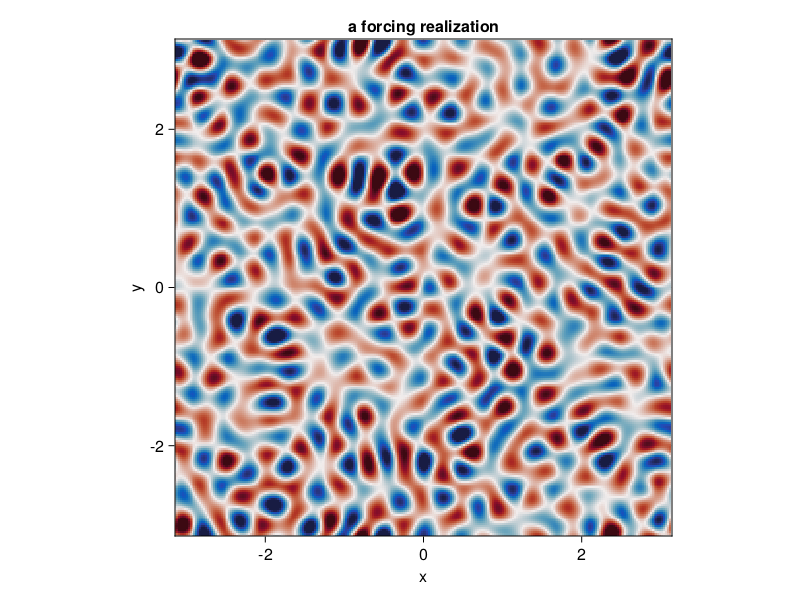

In [9]:
calcF!(vars.Fh, sol, 0.0, clock, vars, params, grid)

fig = Figure()

ax = Axis(fig[1, 1],
          xlabel = "x",
          ylabel = "y",
          aspect = 1,
          title = "a forcing realization",
          limits = ((-Lx/2, Lx/2), (-Ly/2, Ly/2)))

heatmap!(ax, x, y, Array(irfft(vars.Fh, grid.nx));
         colormap = :balance, colorrange = (-200, 200))

fig

## Setting initial conditions

Our initial condition is a fluid at rest.

In [10]:
TwoDNavierStokes.set_ζ!(prob, device_array(dev)(zeros(grid.nx, grid.ny)))

## Diagnostics

Create Diagnostics; the diagnostics are aimed to probe the energy and enstrophy budgets.

In [11]:
E  = Diagnostic(TwoDNavierStokes.energy,                               prob, nsteps=nt) # energy
Rᵋ = Diagnostic(TwoDNavierStokes.energy_dissipation_hypoviscosity,     prob, nsteps=nt) # energy dissipation by drag μ
Dᵋ = Diagnostic(TwoDNavierStokes.energy_dissipation_hyperviscosity,    prob, nsteps=nt) # energy dissipation by drag μ
Wᵋ = Diagnostic(TwoDNavierStokes.energy_work,                          prob, nsteps=nt) # energy work input by forcing
Z  = Diagnostic(TwoDNavierStokes.enstrophy,                            prob, nsteps=nt) # enstrophy
Rᶻ = Diagnostic(TwoDNavierStokes.enstrophy_dissipation_hypoviscosity,  prob, nsteps=nt) # enstrophy dissipation by drag μ
Dᶻ = Diagnostic(TwoDNavierStokes.enstrophy_dissipation_hyperviscosity, prob, nsteps=nt) # enstrophy dissipation by drag μ
Wᶻ = Diagnostic(TwoDNavierStokes.enstrophy_work,                       prob, nsteps=nt) # enstrophy work input by forcing
diags = [E, Dᵋ, Wᵋ, Rᵋ, Z, Dᶻ, Wᶻ, Rᶻ] # a list of Diagnostics passed to `stepforward!` will  be updated every timestep.
nothing # hide

## Time-stepping the `Problem` forward

We step the `Problem` forward in time.

In [12]:
startwalltime = time()
for i = 1:ns
  stepforward!(prob, diags, round(Int, nt/ns))

  TwoDNavierStokes.updatevars!(prob)

  cfl = clock.dt * maximum([maximum(vars.u) / grid.dx, maximum(vars.v) / grid.dy])

  log = @sprintf("step: %04d, t: %.1f, cfl: %.3f, walltime: %.2f min", clock.step, clock.t,
        cfl, (time()-startwalltime)/60)

  println(log)
end

step: 0100, t: 0.5, cfl: 0.165, walltime: 0.03 min
step: 0200, t: 1.0, cfl: 0.259, walltime: 0.06 min
step: 0300, t: 1.5, cfl: 0.280, walltime: 0.08 min
step: 0400, t: 2.0, cfl: 0.337, walltime: 0.10 min


## Plot
Now let's see the final snapshot of the vorticity.

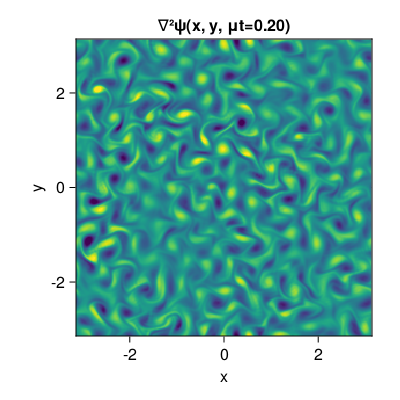

In [13]:
fig = Figure(resolution = (400, 400))

ax = Axis(fig[1, 1];
          xlabel = "x",
          ylabel = "y",
          title = "∇²ψ(x, y, μt=" * @sprintf("%.2f", μ * clock.t) * ")",
          aspect = 1,
          limits = ((-L/2, L/2), (-L/2, L/2)))

heatmap!(ax, x, y, Array(vars.ζ);
         colormap = :viridis, colorrange = (-25, 25))

fig

And finally, we plot the evolution of the energy and enstrophy diagnostics and all terms
involved in the energy and enstrophy budgets. Last, we also check (by plotting) whether
the energy and enstrophy budgets are accurately computed, e.g., $\mathrm{d}E/\mathrm{d}t = W^\varepsilon -
R^\varepsilon - D^\varepsilon$.

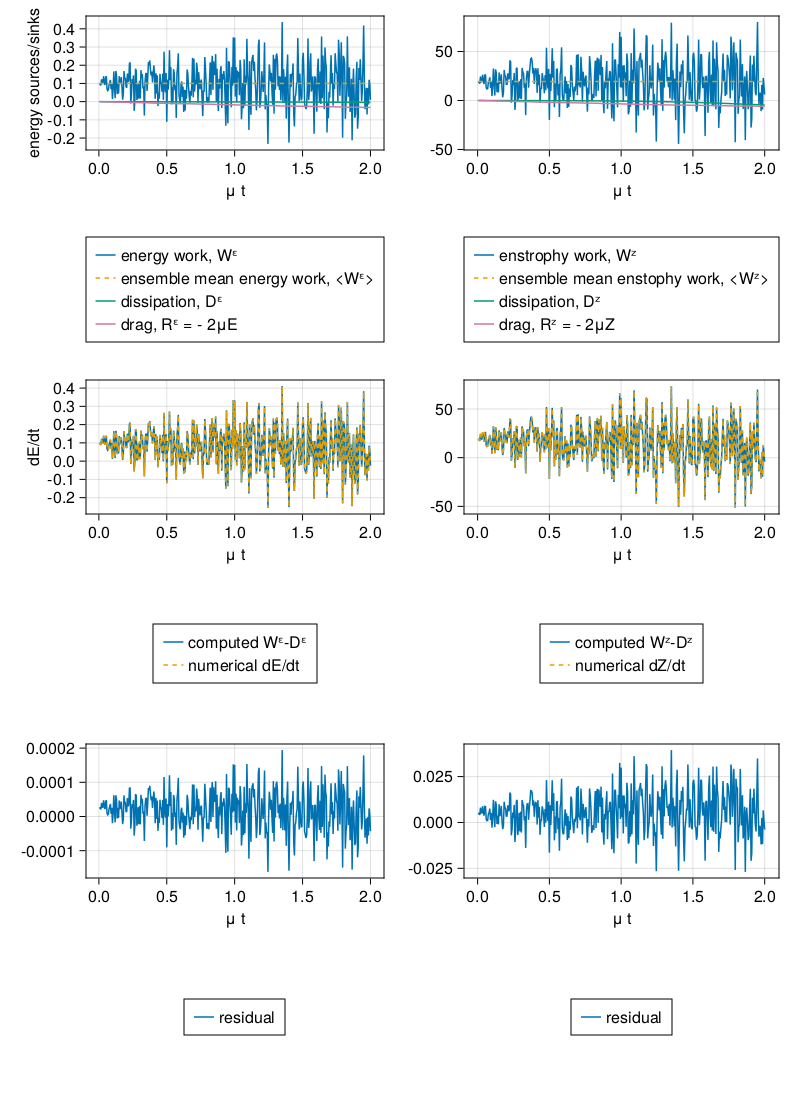

In [14]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid

TwoDNavierStokes.updatevars!(prob)

E, Dᵋ, Wᵋ, Rᵋ, Z, Dᶻ, Wᶻ, Rᶻ = diags

clocktime = round(μ * clock.t, digits=2)

dEdt_numerical = (E[2:E.i] - E[1:E.i-1]) / clock.dt # numerical first-order approximation of energy tendency
dZdt_numerical = (Z[2:Z.i] - Z[1:Z.i-1]) / clock.dt # numerical first-order approximation of enstrophy tendency

dEdt_computed = Wᵋ[2:E.i] + Dᵋ[1:E.i-1] + Rᵋ[1:E.i-1]
dZdt_computed = Wᶻ[2:Z.i] + Dᶻ[1:Z.i-1] + Rᶻ[1:Z.i-1]

residual_E = dEdt_computed - dEdt_numerical
residual_Z = dZdt_computed - dZdt_numerical

εᶻ = parsevalsum(forcing_spectrum / 2, grid) / (grid.Lx * grid.Ly)

t = E.t[2:E.i]

fig = Figure(resolution = (800, 1100))

axis_kwargs = (xlabel = "μ t", )

ax1E = Axis(fig[1, 1]; ylabel = "energy sources/sinks", axis_kwargs...)
ax2E = Axis(fig[3, 1]; ylabel = "dE/dt", axis_kwargs...)
ax3E = Axis(fig[5, 1]; axis_kwargs...)

ax1Z = Axis(fig[1, 2]; axis_kwargs...)
ax2Z = Axis(fig[3, 2]; axis_kwargs...)
ax3Z = Axis(fig[5, 2]; axis_kwargs...)

hWᵋ = lines!(ax1E, t, Wᵋ[2:E.i];   linestyle = :solid)
hε  = lines!(ax1E, t, ε .+ 0t;     linestyle = :dash)
hDᵋ = lines!(ax1E, t, Dᵋ[1:E.i-1]; linestyle = :solid)
hRᵋ = lines!(ax1E, t, Rᵋ[1:E.i-1]; linestyle = :solid)

Legend(fig[2, 1],
       [hWᵋ, hε, hDᵋ, hRᵋ],
       ["energy work, Wᵋ" "ensemble mean energy work, <Wᵋ>" "dissipation, Dᵋ" "drag, Rᵋ = - 2μE"])

hc = lines!(ax2E, t, dEdt_computed; linestyle = :solid)
hn = lines!(ax2E, t, dEdt_numerical; linestyle = :dash)

Legend(fig[4, 1],
       [hc, hn],
       ["computed Wᵋ-Dᵋ" "numerical dE/dt"])

hr = lines!(ax3E, t, residual_E)

Legend(fig[6, 1],
       [hr],
       ["residual"])

hWᶻ = lines!(ax1Z, t, Wᶻ[2:Z.i];  linestyle = :solid)
hεᶻ = lines!(ax1Z, t, εᶻ .+ 0t;    linestyle = :dash)
hDᶻ = lines!(ax1Z, t, Dᶻ[1:Z.i-1]; linestyle = :solid)
hRᶻ = lines!(ax1Z, t, Rᶻ[1:Z.i-1]; linestyle = :solid)

Legend(fig[2, 2],
       [hWᶻ, hεᶻ, hDᶻ, hRᶻ],
       ["enstrophy work, Wᶻ" "ensemble mean enstophy work, <Wᶻ>" "dissipation, Dᶻ" "drag, Rᶻ = - 2μZ"])

hcᶻ = lines!(ax2Z, t, dZdt_computed; linestyle = :solid)
hnᶻ = lines!(ax2Z, t, dZdt_numerical; linestyle = :dash)

Legend(fig[4, 2],
       [hcᶻ, hnᶻ],
       ["computed Wᶻ-Dᶻ" "numerical dZ/dt"])

hrᶻ = lines!(ax3Z, t, residual_Z)

Legend(fig[6, 2],
       [hr],
       ["residual"])

fig

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*